In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")

In [3]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

In [4]:
def add_number(state):
    result=state["num1"]+state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply",update={"sum":result})

In [5]:
state={"num1":10,"num2":20}

In [6]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

### Creating one dummy multiagent

it is for network/collab multiagent

In [7]:
from langchain_core.tools import tool

In [8]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [9]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

In [10]:
llm_with_tool=llm.bind_tools([transfer_to_addition_expert])

In [11]:
response=llm_with_tool.invoke("hi")

In [12]:
response.content

'Hello! How can I assist you today?'

In [13]:
response.tool_calls

[]

In [14]:
response=llm_with_tool.invoke("what is 2+2?")

In [15]:
response.content

''

In [16]:
response.tool_calls

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'call_tlWpVoAWVrB3VFhWRmkluyWe',
  'type': 'tool_call'}]

In [17]:
system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [18]:
messages = [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [19]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [20]:
from typing_extensions import Literal
from langgraph.graph import MessagesState,StateGraph, START,END

In [21]:
def addition_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:

    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

    messages = [{"role": "system", "content": system_prompt}] + state["messages"]


    ai_msg = llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)


    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }

        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [22]:
##Agent2
def multiplication_expert(state:MessagesState)-> Command[Literal["addition_expert", "__end__"]]:

    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )

    messages = [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)

    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="addition_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [23]:
graph=StateGraph(MessagesState)

In [24]:
graph.add_node("addition_expert",addition_expert)
graph.add_node("multiplication_expert",multiplication_expert)

In [25]:
graph.add_edge(START, "addition_expert")

In [26]:
app=graph.compile()


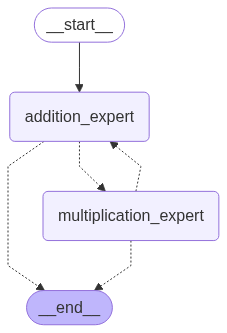

In [41]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='862ee0e0-f9a1-4f91-8d06-0c753be2ecf7'),
  AIMessage(content="First, I'll handle the addition part of the expression: \\(3 + 5 = 8\\).\n\nNext, I'll hand over the multiplication part, \\(8 \\times 12\\), to the multiplication expert.", additional_kwargs={'tool_calls': [{'id': 'call_FyrdFrvjNabdQ6Ljle5wBjom', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 86, 'total_tokens': 145, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff25b2783a', 'id': 'chatcmpl-C2tRvMptF1iTbxaArJvbDwhLiDkPH', 'service_tier'

## With realtime tool

In [28]:
from langchain_community.tools import DuckDuckGoSearchRun

In [29]:
search_tool=DuckDuckGoSearchRun()

import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

/var/folders/w4/92z280zx5ms3x2bzmkk6s2hh0000gp/T/ipykernel_89470/3310200401.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [30]:
search_tool.invoke("who is a current pm of uk?")

[{'title': 'Prime Minister of the United Kingdom',
  'url': 'https://en.wikipedia.org/wiki/Prime_Minister_of_the_United_Kingdom',
  'content': '| Prime Minister of the United Kingdom of Great Britain and Northern Ireland | |\n| --- | --- |\n| Royal arms of His Majesty\'s Government | |\n| Flag of the United Kingdom | |\n| Incumbent Keir Starmer since 5 July 2024 | |\n|  Government of the United Kingdom  Prime Minister\'s Office "Prime Minister\'s Office (United Kingdom)")  Cabinet Office | |\n| Style "Style (form of address)") |  Prime Minister (informal)  The Right Honourable (formal)  His Excellency (diplomatic) | [...] was in response to the 2024 Labour Party freebies controversy, in which the current prime minister, Keir Starmer, having reportedly failed to disclose the amount of gifts and "freebies" received by him, members of his family and cabinet. [...] As of 2025( 58 people (55 men and 3 women) have served as prime minister, the first of whom was Robert Walpole taking office o

In [31]:
from langchain_experimental.utilities import PythonREPL

In [ ]:
repl=PythonREPL() ## pythonREPL is utility that allows you to run python code in the langgraph

In [33]:
code = """
x = 5
y = x * 2
print(y)
"""

In [ ]:
repl.run(code) ## invoke will not work, you need to use run method to run the code in the python repl

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [35]:
from typing import Annotated

In [36]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""

    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [37]:
python_repl_tool

StructuredTool(name='python_repl_tool', description='Use this to execute python code. If you want to see the output of a value,\n    you should print it out with `print(...)`. This is visible to the user.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x12ff9c720>)

In [38]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [59]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [50]:
from langchain_core.messages import BaseMessage, HumanMessage

In [51]:
def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [58]:
#agent1
def research_node(state:MessagesState)->Command[Literal["chart_generator", END]]:
    research_agent=create_react_agent(
        llm,
        tools=[search_tool],
        prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
        )

    result=research_agent.invoke(state)

    # result=[messages:{humanmesssage
    #                 aimessgae
    #                 toolmessage
    #                 aimessage
    #                 toolmessage
    #                 aimessage}]

    goto=get_next_node(result["messages"][-1],"chart_generator")

    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")

    return Command(update={"messages": result["messages"]},goto=goto)

In [53]:
#agent2
def chart_node(state:MessagesState)-> Command[Literal["researcher", END]]:
    chart_agent=create_react_agent(
        llm,
        tools=[python_repl_tool],
        prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
        )
    result=chart_agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(update={"messages": result["messages"]},goto=goto)

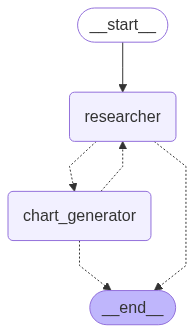

In [60]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
make_system_prompt("You can only do research. You are working with a chart generator colleague.")

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

Bad pipe message: %s [b'q\xce\xa5\xb2\xfb:H\x98\xb3XO\xc1r\x9f\xd9\xd9\x9cy\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003']
Bad pipe message: %s [b'\xdb\x00A\x8e\x98#\xe5\xe6\xe8q\xee\xf8\xc6\x93\xe3D5n\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84']
Bad pipe message: %s [b'\xe3\x15\xeb\xfc\x9d\xe6\x98\x1c<a\xd4dr\x10\xa0G"\xe8\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x

In [ ]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})